In [4]:
import matplotlib.pyplot as plt
from core.utils import load_run_data
import jax.numpy as jnp

# Use a clean style
plt.style.use('seaborn-v0_8-paper') 

def smooth(data, window_size=20):
    """Computes a simple moving average for smoothing."""
    if window_size <= 1:
        return data
    kernel = jnp.ones(window_size) / window_size
    return jnp.convolve(data, kernel, mode='valid')

def plot_experiment(metrics, metric_keys, label, log=False, grad_steps_per_update = 1):
    # We use the 'label' argument for the line legend
    for item in metric_keys:
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        y_smooth = smooth(y, window_size=10)
        x = [i * grad_steps_per_update for i in range(len(y_smooth))]
        plt.plot(x, y_smooth, label=label, linewidth=1.85, alpha = 0.9)
        if log:
            plt.yscale('log')

def plot_experiments(metrics_list, title, metric_keys, run_labels, log=False, grad_steps_per_update = 1):
    plt.figure(figsize=(5, 5))
    plt.style.use('seaborn-v0_8-paper')
    
    # Iterate through both metrics and their corresponding labels
    for metrics, label in zip(metrics_list, run_labels):
        plot_experiment(metrics, metric_keys, label, log, grad_steps_per_update)
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Update", fontsize=12)
    plt.legend(frameon=True, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def read_off_experiments(metrics_list, metric_keys, run_labels, log=False, grad_steps_per_update = 1):
    # Iterate through both metrics and their corresponding labels
    for item in metric_keys:
        for metrics, label in zip(metrics_list, run_labels):
            values = metrics[item]
            final_val = jnp.mean(values[-10:])
            print(f'{label}, {item}, {final_val}')
        
# Execution


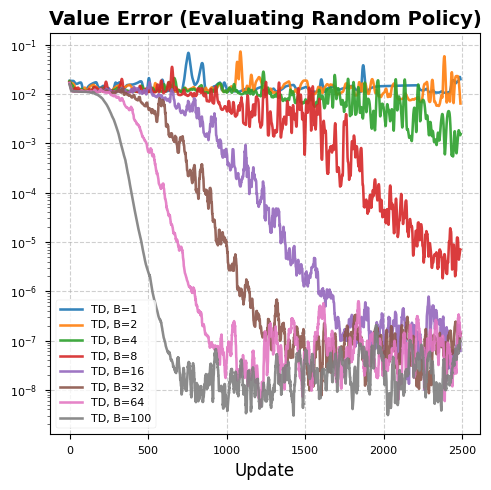

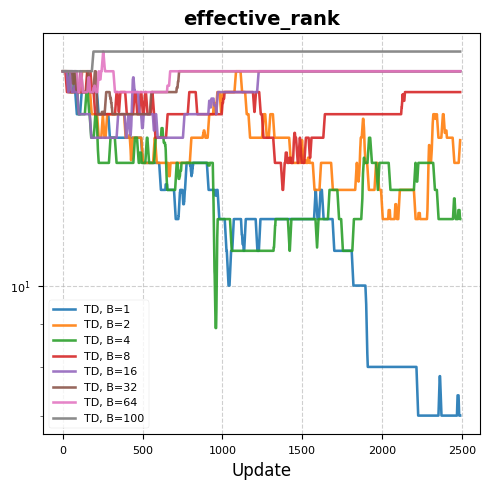

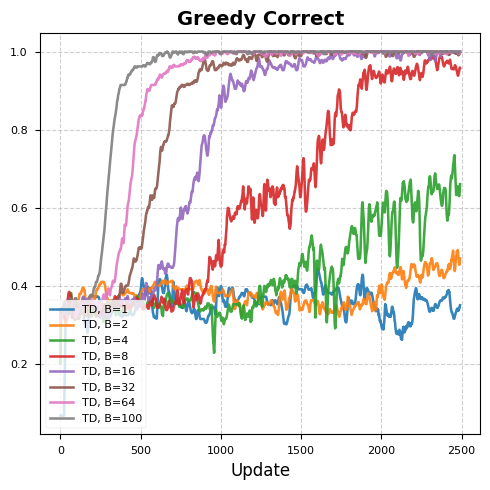

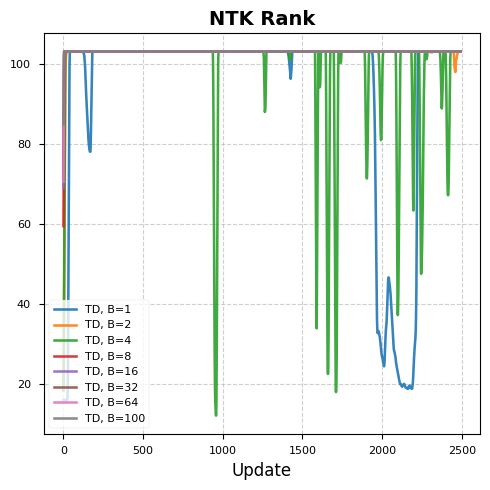

TD, B=1, nn_weighted_VE, 0.014654547907412052
TD, B=2, nn_weighted_VE, 0.013329975306987762
TD, B=4, nn_weighted_VE, 0.00954499002546072
TD, B=8, nn_weighted_VE, 0.0060661956667900085
TD, B=16, nn_weighted_VE, 0.0034782050643116236
TD, B=32, nn_weighted_VE, 0.002429194515570998
TD, B=64, nn_weighted_VE, 0.0017256089486181736
TD, B=100, nn_weighted_VE, 0.0011374314781278372
TD, B=1, effective_rank, 11.900799751281738
TD, B=2, effective_rank, 14.711999893188477
TD, B=4, effective_rank, 13.19279956817627
TD, B=8, effective_rank, 16.147600173950195
TD, B=16, effective_rank, 17.059200286865234
TD, B=32, effective_rank, 17.63800048828125
TD, B=64, effective_rank, 17.823200225830078
TD, B=100, effective_rank, 18.923599243164062
TD, B=1, nn_greedy_correct, 0.35136380791664124
TD, B=2, nn_greedy_correct, 0.3808838129043579
TD, B=4, nn_greedy_correct, 0.4304380714893341
TD, B=8, nn_greedy_correct, 0.620895266532898
TD, B=16, nn_greedy_correct, 0.7678324580192566
TD, B=32, nn_greedy_correct, 0.83

In [5]:

metrics_list = []
run_labels=[]
for b in [1,2,4,8,16, 32,64, 100]:
    config, metrics = load_run_data(f"random_td_subset/sweep_e_1_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'TD, B={b}')

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)

read_off_experiments(metrics_list, ["nn_weighted_VE", "effective_rank", "nn_greedy_correct", "NTK_rank"], run_labels)

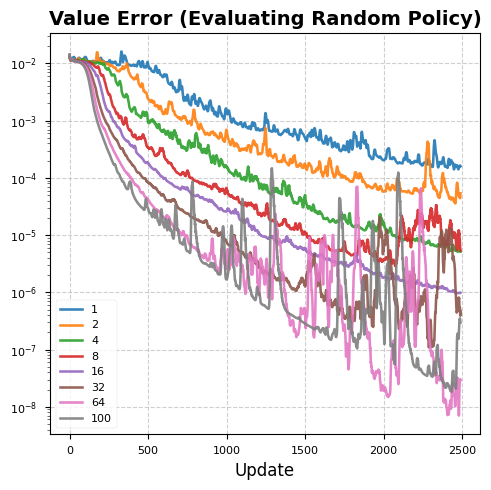

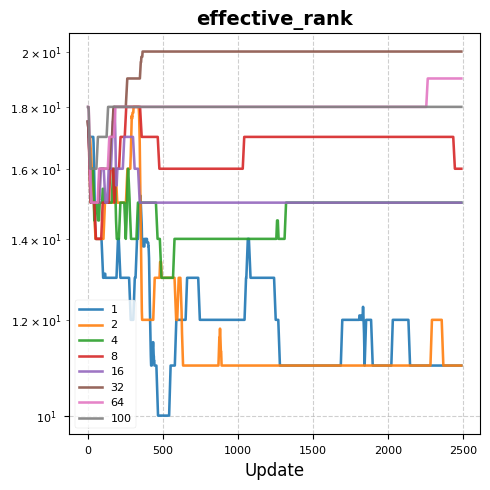

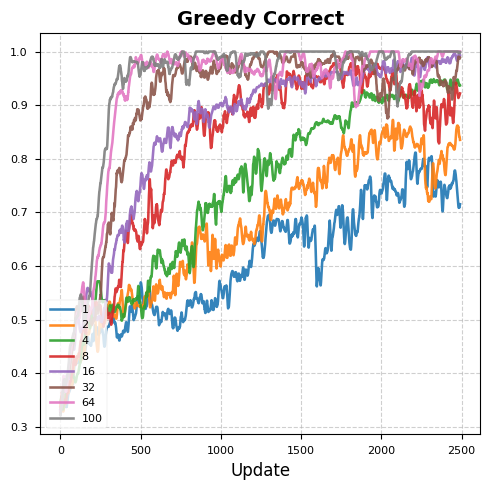

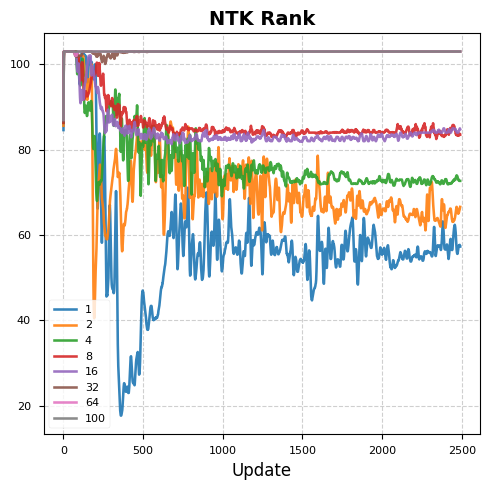

In [7]:
metrics_list = []
run_labels=[]
for b in [1,2,4,8,16, 32,64,100]:
    config, metrics = load_run_data(f"random_mc_subset/sweep_e_1_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(b)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)


In [22]:
import numpy as np

def normalize_entk_to_cosine(eNTK):
    # 1. Extract the diagonal (the squared L2 norms of each state's gradient)
    #    and take the square root to get the actual norms.
    norms = np.sqrt(np.diag(eNTK))
    
    # 2. Create a denominator matrix where entry (i,j) is norms[i] * norms[j]
    denominator = np.outer(norms, norms)
    
    # 3. Divide the raw eNTK by this denominator (add epsilon to prevent div by zero)
    cosine_sim_matrix = eNTK / (denominator + 1e-12)
    
    return cosine_sim_matrix

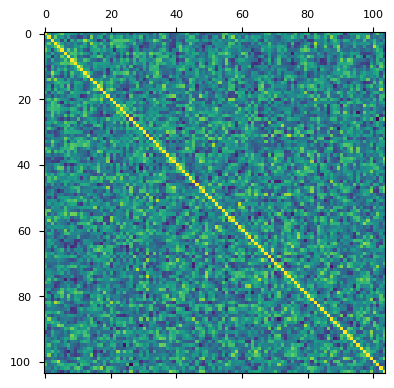

In [23]:
config, metrics = load_run_data(f"random_mc_subset/sweep_e_1_sweep_b_{b}", 'FourRooms-misc', 'results')
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][0]))

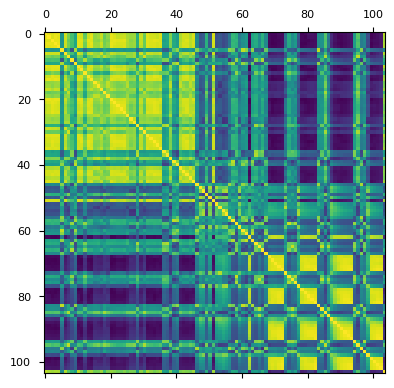

In [24]:
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][2499]))

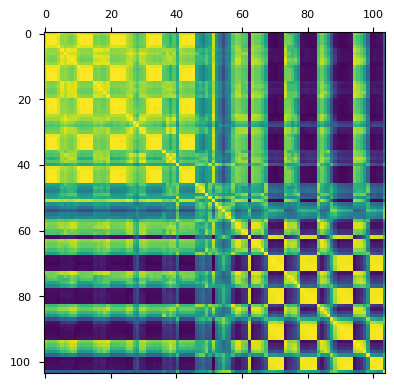

In [26]:
config, metrics = load_run_data(f"random_mc_subset/sweep_e_1_sweep_b_2", 'FourRooms-misc', 'results')
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][2499]))

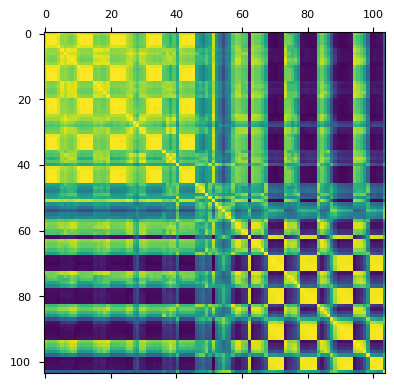

In [30]:
config, metrics = load_run_data(f"random_mc_subset/sweep_e_1_sweep_b_2", 'FourRooms-misc', 'results')
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][2499]))

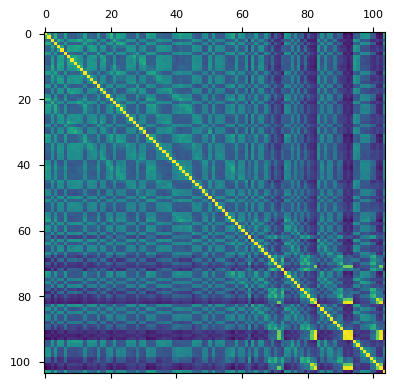

In [28]:
config, metrics = load_run_data(f"random_td_subset/sweep_e_1_sweep_b_64", 'FourRooms-misc', 'results')
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][2499]))

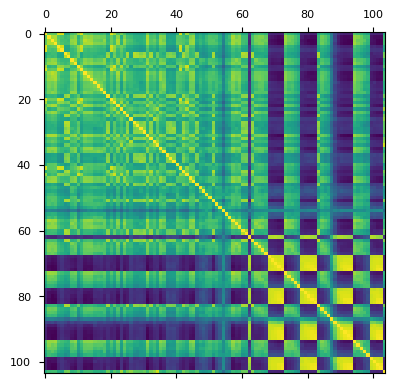

In [29]:
config, metrics = load_run_data(f"random_td_subset/sweep_e_1_sweep_b_4", 'FourRooms-misc', 'results')
plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][2499]))

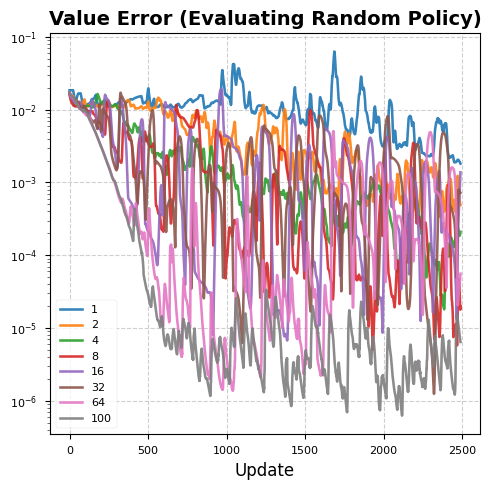

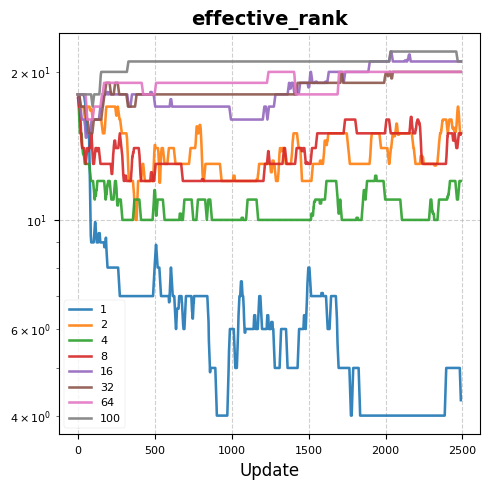

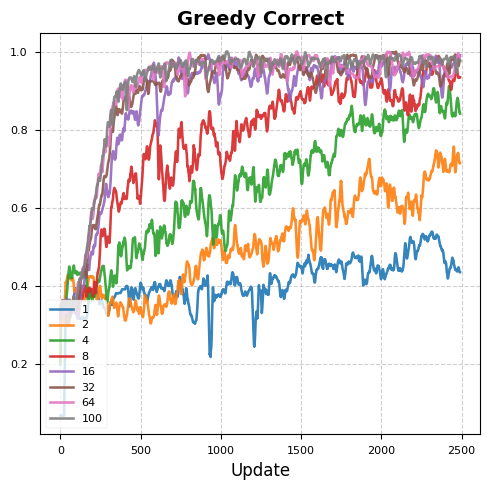

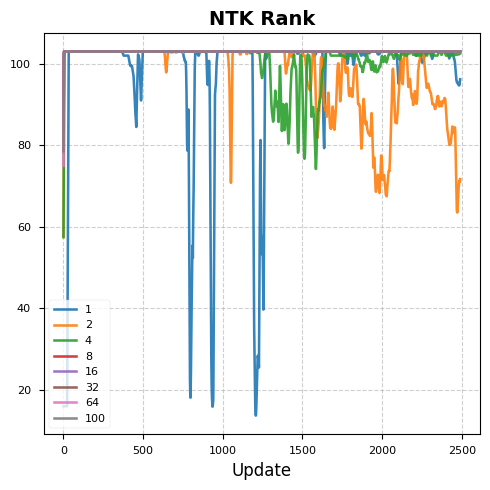

In [ ]:
metrics_list = []
run_labels=[]
for b in [1,2,4,8,16, 32,64, 100]:
    config, metrics = load_run_data(f"random_pfqi_subset/sweep_e_4_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(b)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)

In [ ]:
metrics

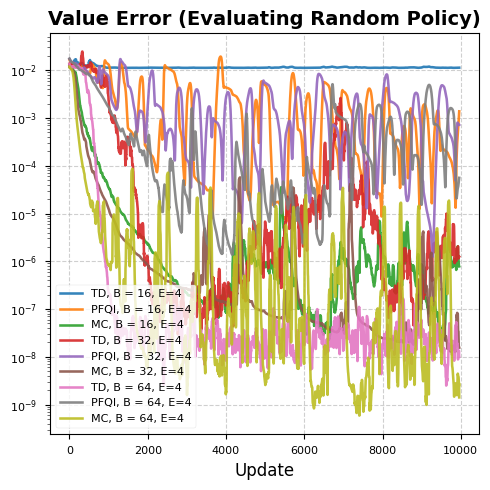

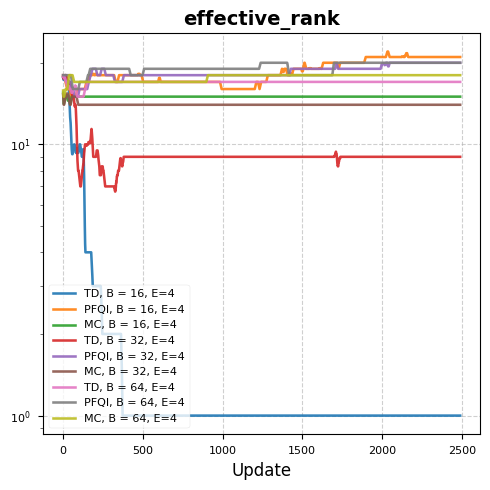

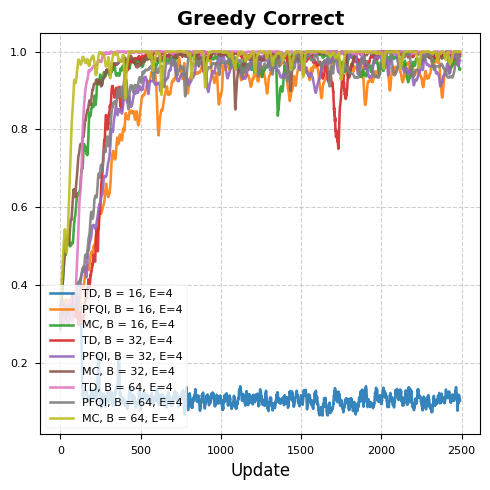

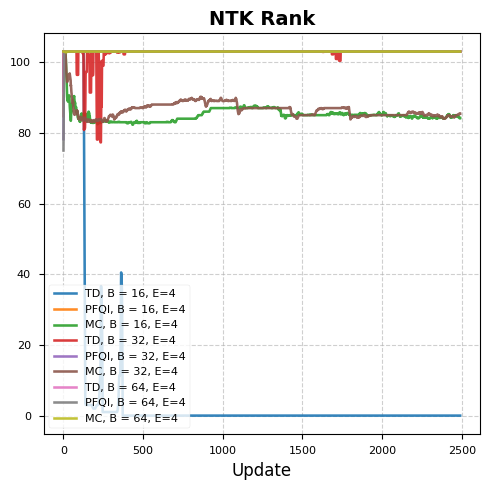

In [35]:
metrics_list = []
run_labels=[]
E = 4
for b in [16, 32, 64]:
    config, metrics = load_run_data(f"random_td_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'TD, B = {b}, E={E}')
    config, metrics = load_run_data(f"random_pfqi_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'PFQI, B = {b}, E={E}')
    config, metrics = load_run_data(f"random_mc_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'MC, B = {b}, E={E}')

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True,
    grad_steps_per_update = config['NUM_EPOCHS']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)

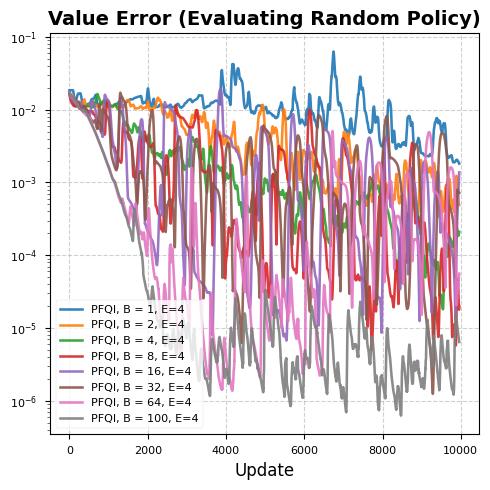

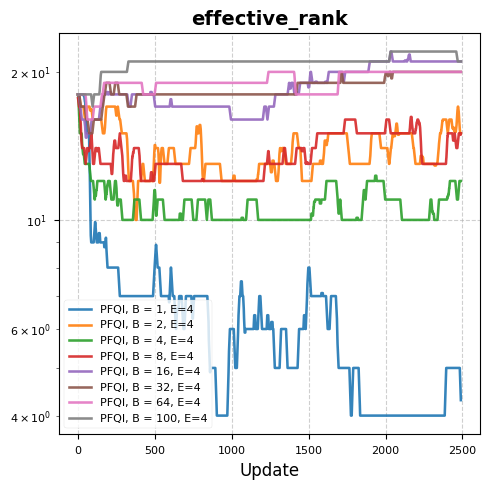

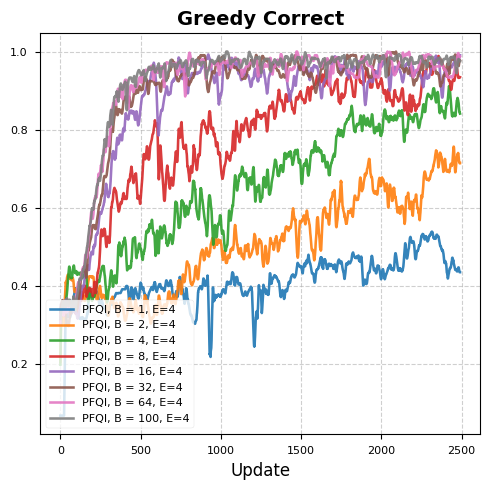

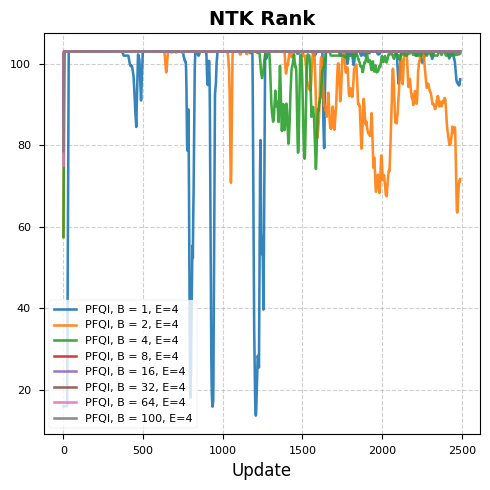

PFQI, B = 1, E=4, nn_weighted_VE, 0.011129415594041348
PFQI, B = 2, E=4, nn_weighted_VE, 0.005175688304007053
PFQI, B = 4, E=4, nn_weighted_VE, 0.0027547709178179502
PFQI, B = 8, E=4, nn_weighted_VE, 0.002490753773599863
PFQI, B = 16, E=4, nn_weighted_VE, 0.0030153663828969
PFQI, B = 32, E=4, nn_weighted_VE, 0.0027365158312022686
PFQI, B = 64, E=4, nn_weighted_VE, 0.0011925875442102551
PFQI, B = 100, E=4, nn_weighted_VE, 0.0008687343215569854
PFQI, B = 1, E=4, effective_rank, 6.212399959564209
PFQI, B = 2, E=4, effective_rank, 13.821999549865723
PFQI, B = 4, E=4, effective_rank, 10.740399360656738
PFQI, B = 8, E=4, effective_rank, 13.571599960327148
PFQI, B = 16, E=4, effective_rank, 18.50079917907715
PFQI, B = 32, E=4, effective_rank, 18.511199951171875
PFQI, B = 64, E=4, effective_rank, 19.119998931884766
PFQI, B = 100, E=4, effective_rank, 20.920000076293945
PFQI, B = 1, E=4, NTK_rank, 97.68199920654297
PFQI, B = 2, E=4, NTK_rank, 97.18560028076172
PFQI, B = 4, E=4, NTK_rank, 100.68

In [37]:
# PFQI
metrics_list = []
run_labels=[]
E = 4
for b in [1, 2, 4, 8, 16, 32, 64, 100]:
    config, metrics = load_run_data(f"random_pfqi_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'PFQI, B = {b}, E={E}')


plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True,
    grad_steps_per_update = config['NUM_EPOCHS']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)

read_off_experiments(metrics_list, ["nn_weighted_VE", "effective_rank", "NTK_rank"], run_labels)

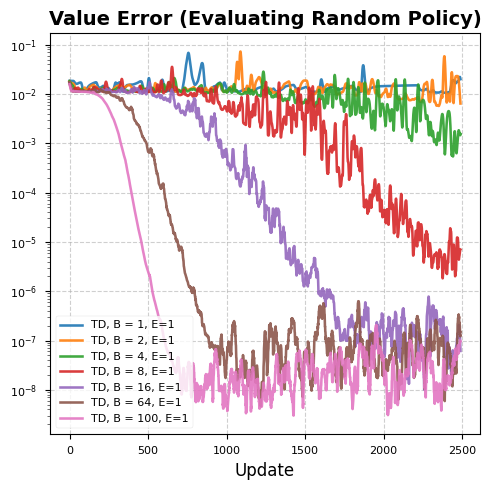

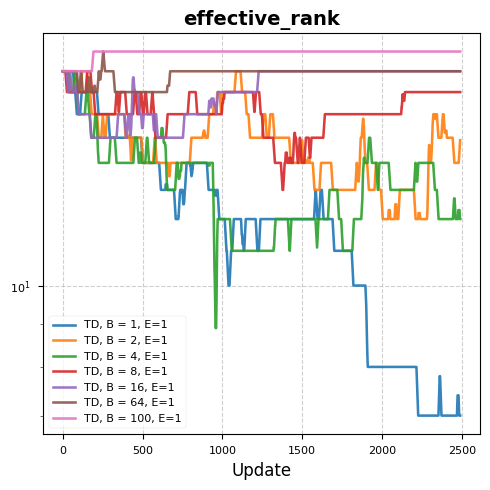

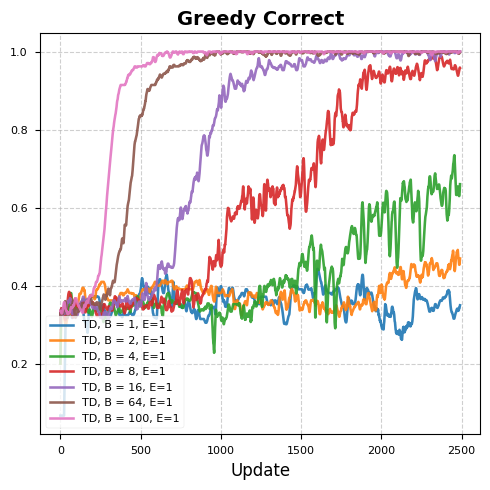

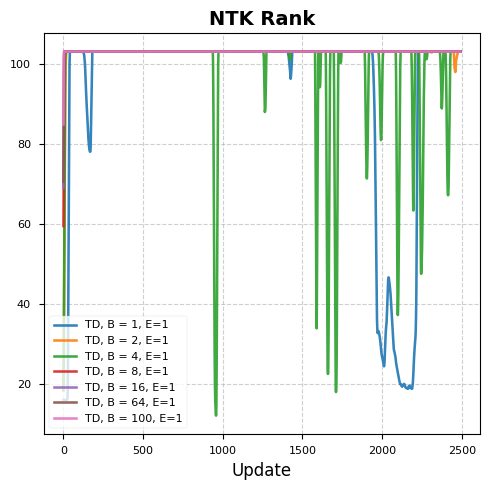

TD, B = 1, E=1, nn_weighted_VE, 0.014654547907412052
TD, B = 2, E=1, nn_weighted_VE, 0.013329975306987762
TD, B = 4, E=1, nn_weighted_VE, 0.00954499002546072
TD, B = 8, E=1, nn_weighted_VE, 0.0060661956667900085
TD, B = 16, E=1, nn_weighted_VE, 0.0034782050643116236
TD, B = 64, E=1, nn_weighted_VE, 0.0017256089486181736
TD, B = 100, E=1, nn_weighted_VE, 0.0011374314781278372
TD, B = 1, E=1, effective_rank, 11.900799751281738
TD, B = 2, E=1, effective_rank, 14.711999893188477
TD, B = 4, E=1, effective_rank, 13.19279956817627
TD, B = 8, E=1, effective_rank, 16.147600173950195
TD, B = 16, E=1, effective_rank, 17.059200286865234
TD, B = 64, E=1, effective_rank, 17.823200225830078
TD, B = 100, E=1, effective_rank, 18.923599243164062
TD, B = 1, E=1, nn_greedy_correct, 0.35136380791664124
TD, B = 2, E=1, nn_greedy_correct, 0.3808838129043579
TD, B = 4, E=1, nn_greedy_correct, 0.4304380714893341
TD, B = 8, E=1, nn_greedy_correct, 0.620895266532898
TD, B = 16, E=1, nn_greedy_correct, 0.76783245

In [32]:
metrics_list = []
run_labels=[]
E = 1
for b in [1, 2, 4, 8, 16, 64, 100]:
    config, metrics = load_run_data(f"random_td_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'TD, B = {b}, E={E}')
    # config, metrics = load_run_data(f"random_mc_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    # metrics_list.append(metrics)
    # run_labels.append(f'MC, B = {b}, E={E}')

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True,
    grad_steps_per_update = config['NUM_EPOCHS']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)
read_off_experiments(metrics_list, ["nn_weighted_VE", "effective_rank", "nn_greedy_correct", "NTK_rank"], run_labels)

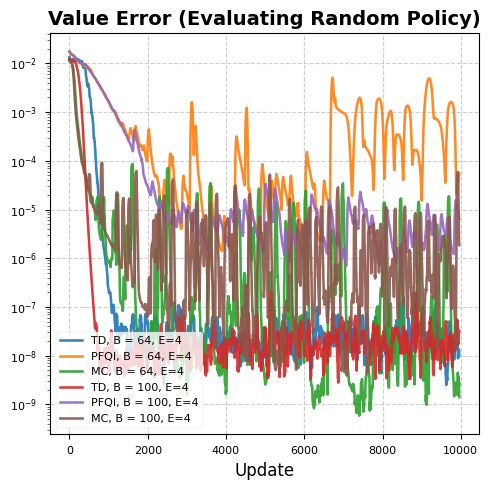

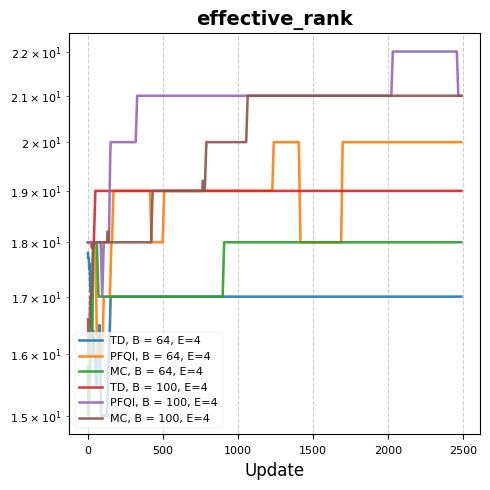

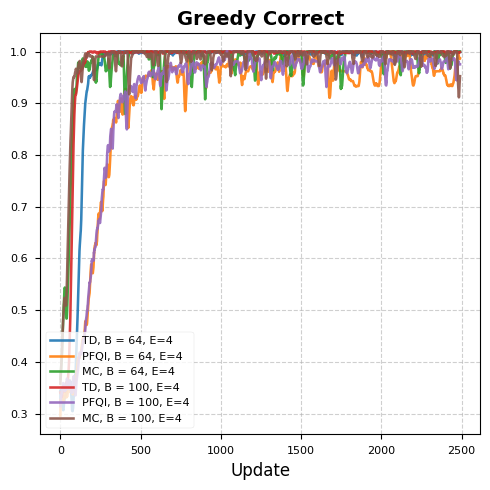

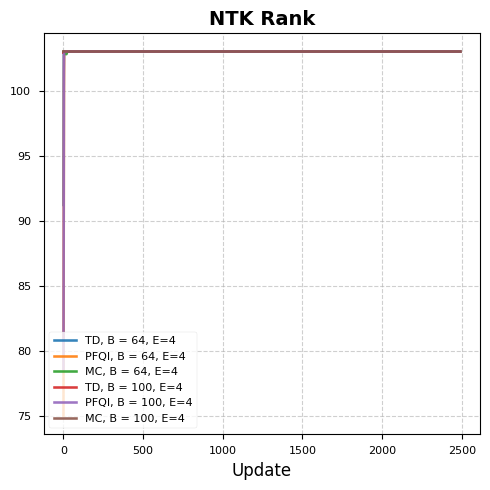

TD, B = 64, E=4, nn_weighted_VE, 0.0005364786484278738
PFQI, B = 64, E=4, nn_weighted_VE, 0.0011925875442102551
MC, B = 64, E=4, nn_weighted_VE, 0.00016266046441160142
TD, B = 100, E=4, nn_weighted_VE, 0.00028803900931961834
PFQI, B = 100, E=4, nn_weighted_VE, 0.0008687343215569854
MC, B = 100, E=4, nn_weighted_VE, 0.00014819056377746165
TD, B = 64, E=4, effective_rank, 16.938400268554688
PFQI, B = 64, E=4, effective_rank, 19.119998931884766
MC, B = 64, E=4, effective_rank, 17.63159942626953
TD, B = 100, E=4, effective_rank, 18.979999542236328
PFQI, B = 100, E=4, effective_rank, 20.920000076293945
MC, B = 100, E=4, effective_rank, 20.06999969482422
TD, B = 64, E=4, nn_greedy_correct, 0.961531400680542
PFQI, B = 64, E=4, nn_greedy_correct, 0.9010666608810425
MC, B = 64, E=4, nn_greedy_correct, 0.974259078502655
TD, B = 100, E=4, nn_greedy_correct, 0.9775427579879761
PFQI, B = 100, E=4, nn_greedy_correct, 0.9098552465438843
MC, B = 100, E=4, nn_greedy_correct, 0.9782781004905701
TD, B = 

In [34]:
metrics_list = []
run_labels=[]
E = 4
for b in [64, 100]:
    config, metrics = load_run_data(f"random_td_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'TD, B = {b}, E={E}')
    
    config, metrics = load_run_data(f"random_pfqi_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'PFQI, B = {b}, E={E}')

    config, metrics = load_run_data(f"random_mc_subset/sweep_e_{E}_sweep_b_{b}", 'FourRooms-misc', 'results')
    metrics_list.append(metrics)
    run_labels.append(f'MC, B = {b}, E={E}')

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    metric_keys=['nn_weighted_VE'],
    title="Value Error (Evaluating Random Policy)",
    log = True,
    grad_steps_per_update = config['NUM_EPOCHS']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="effective_rank",
    metric_keys=['effective_rank'],
    log = True
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="Greedy Correct",
    metric_keys=['nn_greedy_correct']
)

plot_experiments(
    metrics_list=metrics_list,
    run_labels=run_labels,
    title="NTK Rank",
    metric_keys=['NTK_rank']
)
read_off_experiments(metrics_list, ["nn_weighted_VE", "effective_rank", "nn_greedy_correct", "NTK_rank"], run_labels)

In [23]:
import matplotlib.pyplot as plt
from core.utils import load_run_data

plt.style.use('seaborn-v0_8-paper') 

def plot_experiment_dual_axis(metrics, title, y1_keys, y2_keys, y1_labels=None, y2_labels=None, ax1_title = "Bellman Error (BE)", ax2_title = "Value Error (VE)"):
    if y1_labels is None: y1_labels = y1_keys
    if y2_labels is None: y2_labels = y2_keys
    
    fig, ax1 = plt.subplots(figsize=(6, 5))
    
    # Track all lines and labels for a single unified legend
    lines = []
    labels = []

    # Plot Primary Y-Axis (Left)
    ax1.set_xlabel("Updates (i)", fontsize=12)
    ax1.set_ylabel(ax1_title, fontsize=12, color='navy')
    ax1.tick_params(axis='y', labelcolor='navy')
    
    # Using a classic color mapping strategy to keep axes distinct
    y1_colors = ['#1f77b4', '#aec7e8'] 
    for item, label, color in zip(y1_keys, y1_labels, y1_colors):
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        line = ax1.plot(y, label=label, linewidth=2, color=color)
        lines.extend(line)
        labels.append(label)

    # Create Secondary Y-Axis (Right)
    ax2 = ax1.twinx()
    ax2.set_ylabel(ax2_title, fontsize=12, color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')
    
    y2_colors = ['#d62728', '#ff9896']
    for item, label, color in zip(y2_keys, y2_labels, y2_colors):
        values = metrics[item]
        y = values.mean(0) if values.ndim > 1 else values
        line = ax2.plot(y, label=label, linewidth=2, color=color, linestyle='--')
        lines.extend(line)
        labels.append(label)

    # Visual tuning
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Merge legends from both axes into one box
    ax1.legend(lines, labels, frameon=True, loc='upper right')
    
    plt.tight_layout()
    plt.show()

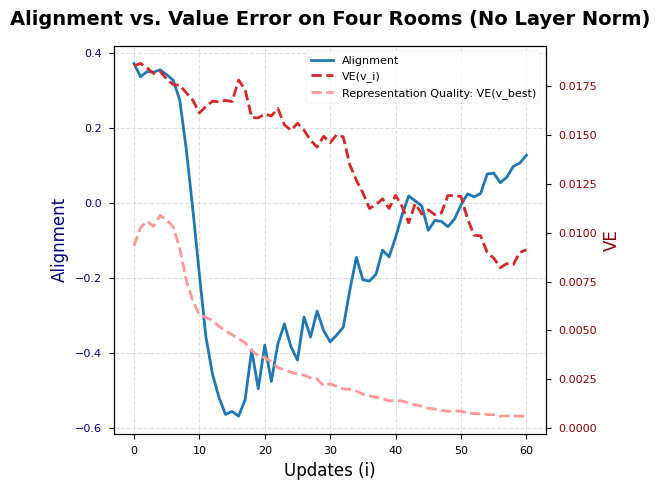

In [ ]:
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Alignment vs. Value Error on Four Rooms (No Layer Norm)",
    y1_keys=['alignment'],
    y2_keys=['nn_weighted_VE', 'VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['VE(v_i)', 'Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

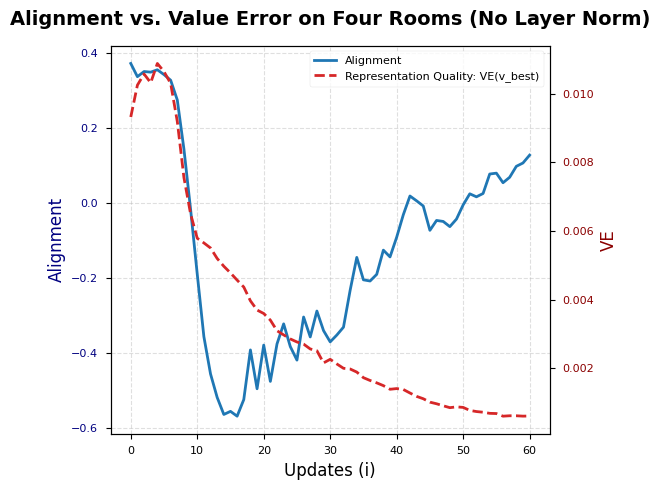

In [ ]:
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Alignment vs. Value Error on Four Rooms (No Layer Norm)",
    y1_keys=['alignment'],
    y2_keys=['VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

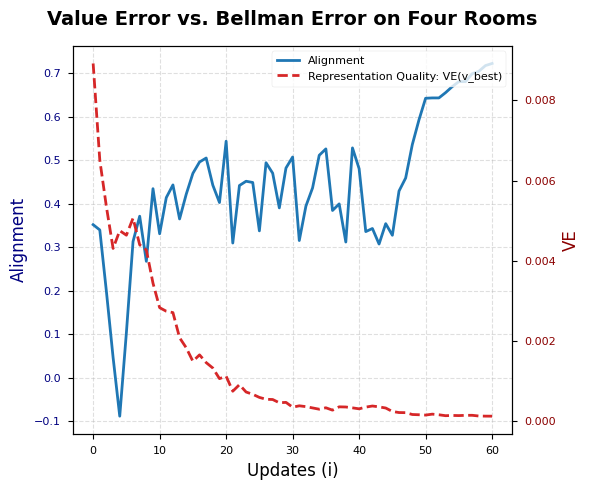

Array(0.00020236, dtype=float32)

In [ ]:
td_config, td_metrics = load_run_data("random_td/layer_norm", 'FourRooms-misc', 'results')
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Value Error vs. Bellman Error on Four Rooms",
    y1_keys=['alignment'],
    y2_keys=['VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE')
# td_metrics['VR_weighted_VE'].min()
td_metrics['nn_weighted_VE'].min()

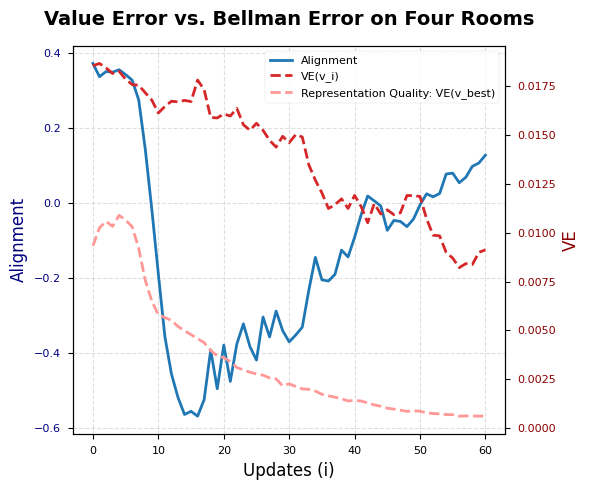

In [ ]:
td_config, td_metrics = load_run_data("random_td/no_layer_norm", 'FourRooms-misc', 'results')
plot_experiment_dual_axis(
    metrics=td_metrics, 
    title="Value Error vs. Bellman Error on Four Rooms",
    y1_keys=['alignment'],
    y2_keys=['nn_weighted_VE', 'VR_weighted_VE'],
    y1_labels=['Alignment'],
    y2_labels=['VE(v_i)', 'Representation Quality: VE(v_best)'],
    ax1_title='Alignment',
    ax2_title='VE'
)

In [ ]:
td_metrics['nn_weighted_VE'].min()

Array(0.00821082, dtype=float32)

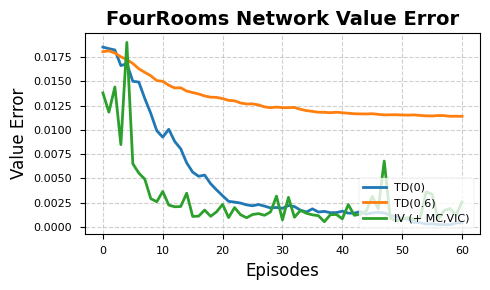

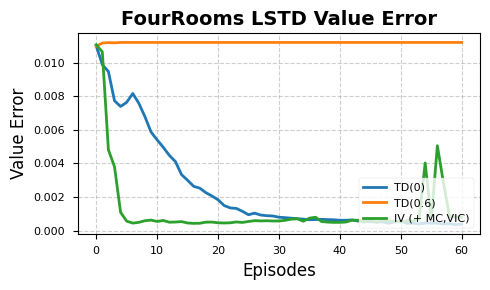

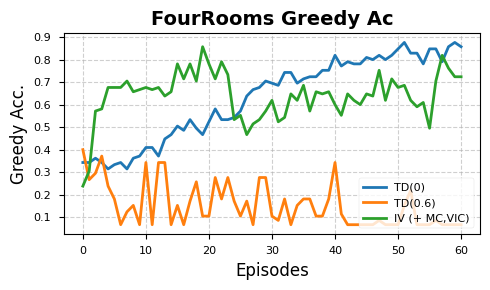

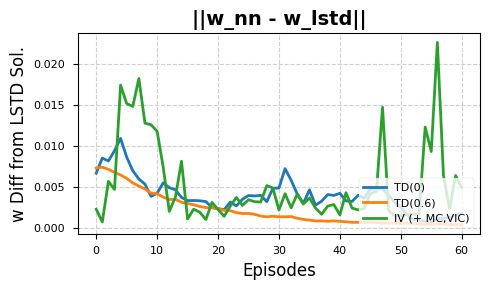

In [ ]:
# random_td_config, random_td_metrics = load_run_data("random_td/20260514_162117", 'FourRooms-misc', 'results')
random_td_config, random_td_metrics = load_run_data("random_td/20260518_170809", 'FourRooms-misc', 'results')

random_tdlambda_config, random_tdlambda_metrics = load_run_data("random_td/gae_lambda_06", 'FourRooms-misc', 'results')
random_iv_config, random_iv_metrics = load_run_data("random_iv_model_vic_mc/20260514_170412", 'FourRooms-misc', 'results')

runs = {'TD(0)': random_td_metrics['nn_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['nn_weighted_VE'],'IV (+ MC,VIC)': random_iv_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Network Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['LSTD_weighted_VE'],'TD(0.6)': random_tdlambda_metrics['LSTD_weighted_VE'], 'IV (+ MC,VIC)': random_iv_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms LSTD Value Error", y_label = "Value Error")

runs = {'TD(0)': random_td_metrics['nn_greedy_correct'],'TD(0.6)': random_tdlambda_metrics['nn_greedy_correct'] ,  'IV (+ MC,VIC)': random_iv_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD(0)': random_td_metrics['nn_lstd_diff'],'TD(0.6)': random_tdlambda_metrics['nn_lstd_diff']  , 'IV (+ MC,VIC)': random_iv_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

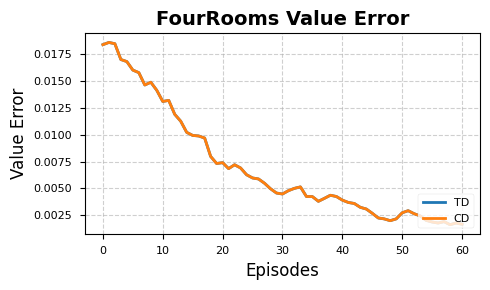

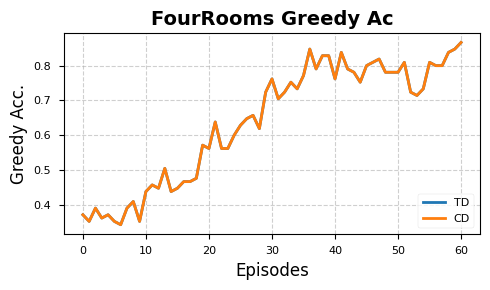

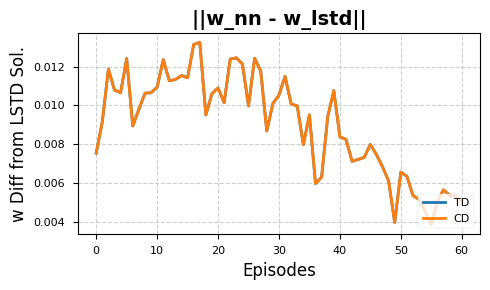

In [ ]:
td_config, td_metrics = load_run_data("random_td/no_interfering_factors", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/no_interfering_factors", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

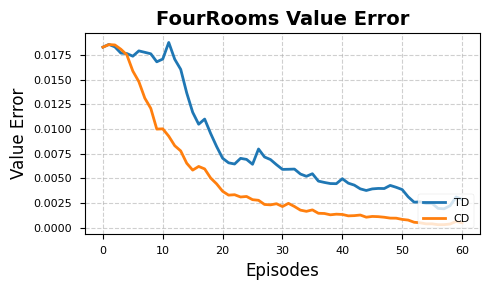

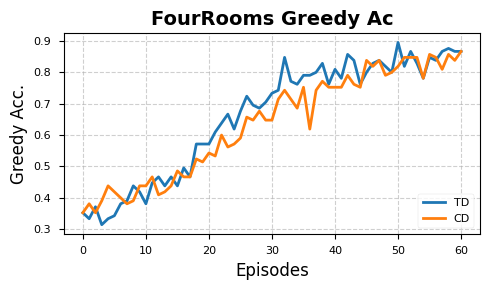

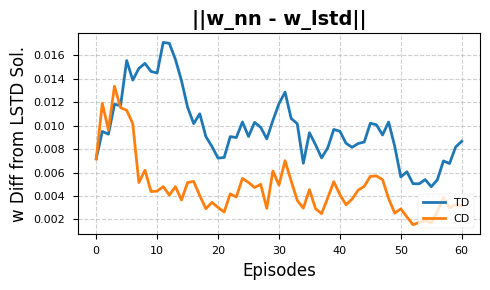

In [ ]:
td_config, td_metrics = load_run_data("random_td/20260513_163216", 'FourRooms-misc', 'results')
cd_config, cd_metrics = load_run_data("random_cd/20260513_150359", 'FourRooms-misc', 'results')
runs = {'TD': td_metrics['nn_weighted_VE'], 'CD': cd_metrics['nn_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'TD': td_metrics['nn_greedy_correct'], 'CD': cd_metrics['nn_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'TD': td_metrics['nn_lstd_diff'], 'CD': cd_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

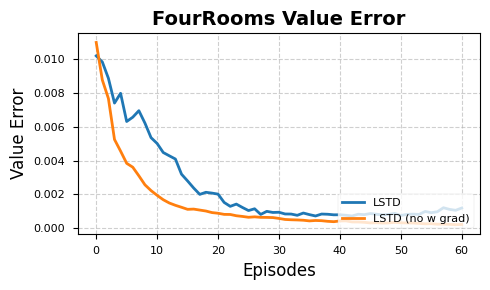

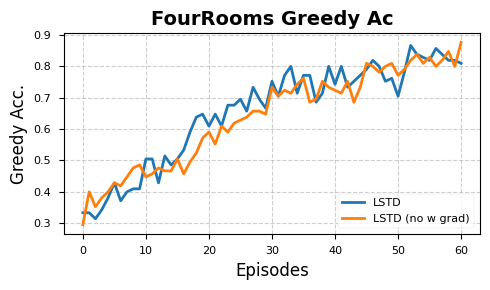

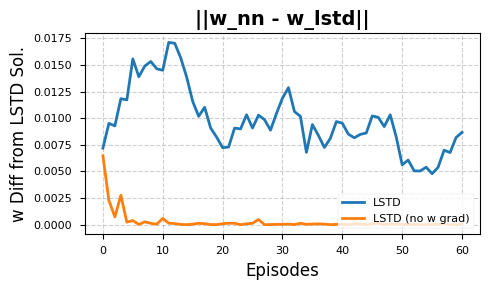

In [ ]:
lstd_config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
lstd_cd_config, lstd_cd_metrics = load_run_data("random_lstd/20260513_154513", 'FourRooms-misc', 'results')
lstd_nw_config, lstd_nw_metrics = load_run_data("random_lstd/20260513_160625", 'FourRooms-misc', 'results')

runs = {'LSTD': td_metrics['LSTD_weighted_VE'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_weighted_VE']}
plot_rl_results(runs, title="FourRooms Value Error", y_label = "Value Error")
runs = {'LSTD': td_metrics['LSTD_greedy_correct'], 'LSTD (no w grad)': lstd_nw_metrics['LSTD_greedy_correct']}
plot_rl_results(runs, title="FourRooms Greedy Ac", y_label = "Greedy Acc.")

runs = {'LSTD': td_metrics['nn_lstd_diff'], 'LSTD (no w grad)': lstd_nw_metrics['nn_lstd_diff']}
plot_rl_results(runs, title="||w_nn - w_lstd||", y_label = "w Diff from LSTD Sol.")

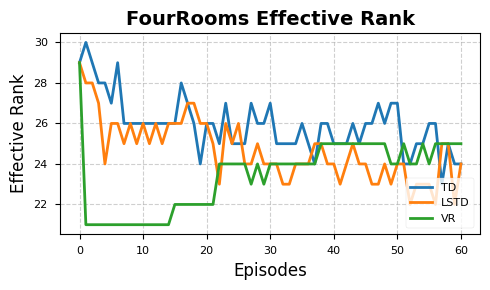

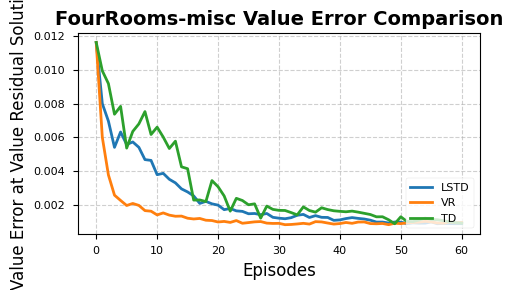

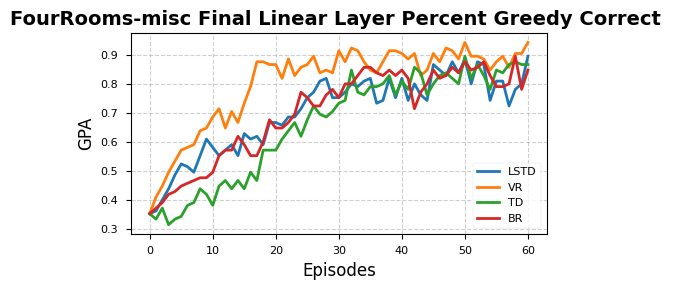

In [ ]:
td_config, td_metrics = load_run_data("random_td/20260511_144250", 'FourRooms-misc', 'results')
config, lstd_metrics = load_run_data("random_lstd/20260511_145036", 'FourRooms-misc', 'results')
config, vr_metrics = load_run_data("random_vr/20260511_145817", 'FourRooms-misc', 'results')
config, br_metrics = load_run_data("random_br/20260511_145516", 'FourRooms-misc', 'results')

runs = {
    "TD": td_metrics['effective_rank'],
    "LSTD": lstd_metrics['effective_rank'],
    "VR": vr_metrics['effective_rank'],
    # "BR": br_metrics['effective_rank']
}
plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

runs = {
    "LSTD": lstd_metrics['VR_uniform_VE'],
    "VR": vr_metrics['VR_uniform_VE'],
    "TD": td_metrics['VR_uniform_VE'],
    # "BR": br_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")

runs = {
    "LSTD": lstd_metrics['nn_greedy_correct'],
    "VR": vr_metrics['nn_greedy_correct'],
    "TD": td_metrics['nn_greedy_correct'],
    "BR": br_metrics['nn_greedy_correct']
}

plot_rl_results(runs, title="FourRooms-misc Final Linear Layer Percent Greedy Correct ", y_label = "GPA")

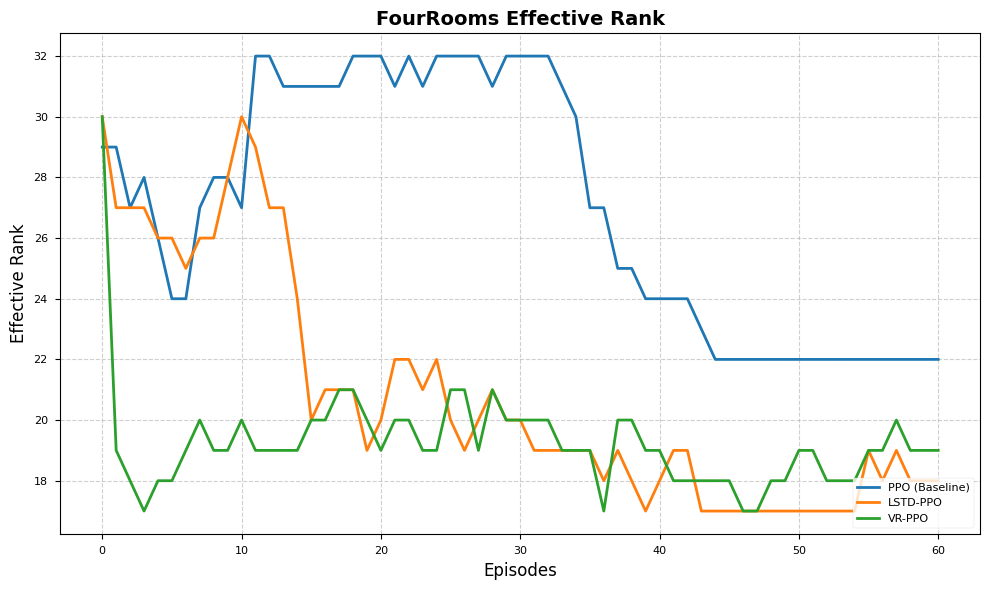

In [ ]:

runs = {
    "PPO (Baseline)": metrics['effective_rank'],
    "LSTD-PPO": lstd_ppo_metrics['effective_rank'],
    "VR-PPO": vr_ppo_metrics['effective_rank']
}

plot_rl_results(runs, title="FourRooms Effective Rank", y_label = "Effective Rank")

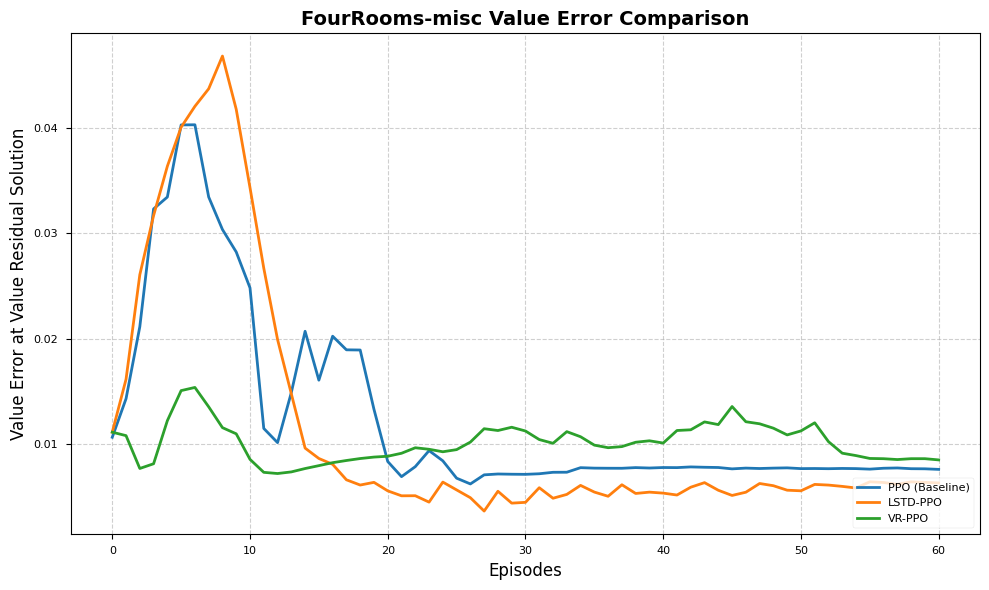

In [ ]:
runs = {
    "PPO (Baseline)": metrics['VR_uniform_VE'],
    "LSTD-PPO": lstd_ppo_metrics['VR_uniform_VE'],
    "VR-PPO": vr_ppo_metrics['VR_uniform_VE']
}

plot_rl_results(runs, title="FourRooms-misc Value Error Comparison", y_label = "Value Error at Value Residual Solution")


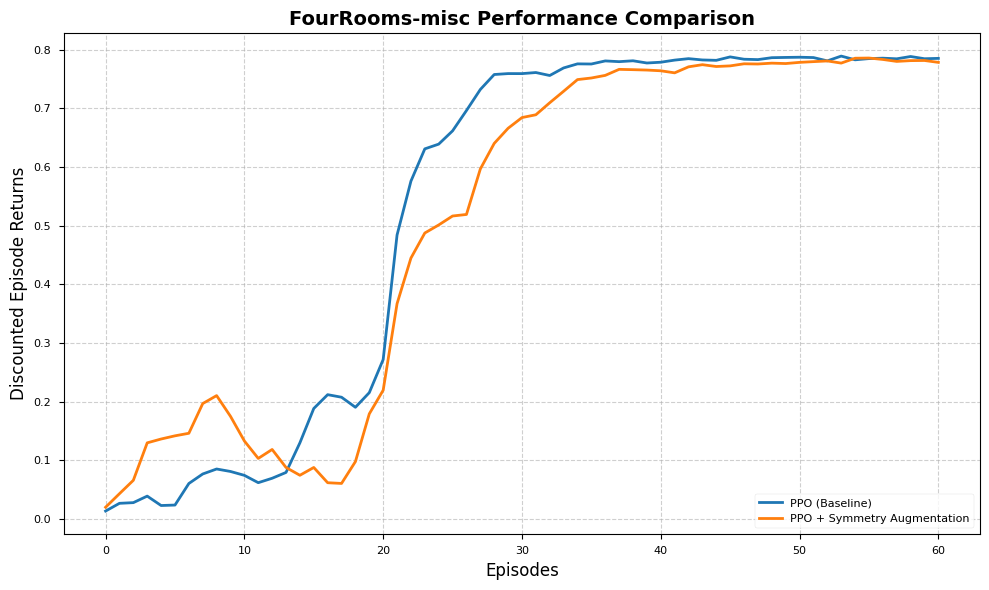

In [ ]:
# results/ppo_symmetry_augmentation/20260511_161729/FourRooms-misc/Weightedconfig


ppoconfig, metrics = load_run_data("ppo/20260510_092335", 'FourRooms-misc', 'results')
ppoconfig, symmetrics = load_run_data("ppo_symmetry_augmentation/20260511_161729", 'FourRooms-misc', 'results')

runs = {
    "PPO (Baseline)": metrics['returned_discounted_episode_returns'],
    "PPO + Symmetry Augmentation": symmetrics['returned_discounted_episode_returns']
    
}

plot_rl_results(runs, title="FourRooms-misc Performance Comparison")